In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Path to dataset files: /kaggle/input/online-retail-ii-uci


In [4]:
import os

os.listdir(path)

['online_retail_II.csv']

In [5]:
import pandas as pd
import os

csv_file = os.path.join(path, "online_retail_II.csv")  # replace with the actual filename if different
df = pd.read_csv(csv_file)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print(df.shape)
print(df.columns.tolist())
df.head()

(1067371, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.columns = [c.strip() for c in df.columns]

rename_map = {
    'Customer ID': 'CustomerID',
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice',
}
df = df.rename(columns=rename_map)

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     243007
Country             0
dtype: int64


## DATA CLEANING

In [8]:
df = df.dropna(subset=['CustomerID'])

In [9]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]


In [10]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]


In [11]:
df = df.drop_duplicates()


In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [14]:
print("Shape after cleaning:", df.shape)
print("Unique customers:", df['CustomerID'].nunique())
df.head()

Shape after cleaning: (779425, 9)
Unique customers: 5878


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## RFM ENGINEERING

In [15]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)


Snapshot date: 2011-12-10 12:50:00


In [16]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

In [17]:
print(rfm.shape)
rfm.head()

(5878, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [18]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,342.280000
50%,15314.500000,96.000000,3.000000,867.740000
75%,16797.750000,380.000000,7.000000,2248.305000
max,18287.000000,739.000000,398.000000,580987.040000


In [19]:
import numpy as np
for col in ['Recency', 'Frequency', 'Monetary']:
    cap = rfm[col].quantile(0.99)
    rfm[col] = np.where(rfm[col] > cap, cap, rfm[col])

print(rfm.describe())

         CustomerID      Recency    Frequency      Monetary
count   5878.000000  5878.000000  5878.000000   5878.000000
mean   15315.313542   201.257741     5.785471   2304.291717
std     1715.572666   209.151082     7.630332   4254.584005
min    12346.000000     1.000000     1.000000      2.950000
25%    13833.250000    26.000000     1.000000    342.280000
50%    15314.500000    96.000000     3.000000    867.740000
75%    16797.750000   380.000000     7.000000   2248.305000
max    18287.000000   726.000000    46.000000  29205.901000


In [20]:
from sklearn.preprocessing import StandardScaler


In [21]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print(rfm_scaled.shape)
rfm_scaled.head()

(5878, 3)


,Recency,Frequency,Monetary
0,0.596473,0.814520,6.323508
1,-0.952779,0.290252,0.615210
2,-0.603719,-0.102949,-0.066967
3,-0.871491,-0.234016,0.499362
4,0.519966,-0.627218,-0.463044


In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [23]:
inertia = []
sil_scores = []
K_range = range(2, 11)

In [24]:
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

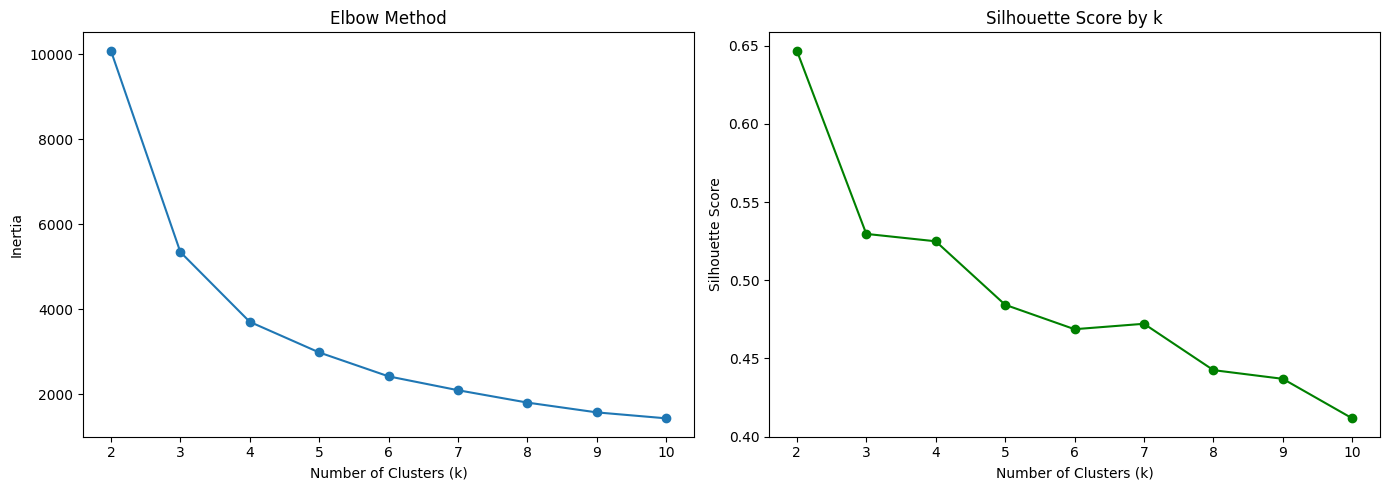

Suggested optimal k (by silhouette score): 2


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"Suggested optimal k (by silhouette score): {best_k}")

In [26]:
N_CLUSTERS = 4
print(f"Using N_CLUSTERS = {N_CLUSTERS}")

Using N_CLUSTERS = 4


In [27]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN


In [28]:
from sklearn.mixture import GaussianMixture


In [29]:
results = {}
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
results['KMeans'] = kmeans.fit_predict(rfm_scaled)

In [30]:
hier = AgglomerativeClustering(n_clusters=N_CLUSTERS)
results['Hierarchical'] = hier.fit_predict(rfm_scaled)

In [31]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
results['DBSCAN'] = dbscan.fit_predict(rfm_scaled)

In [32]:
gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=42)
results['GMM'] = gmm.fit_predict(rfm_scaled)

In [33]:
for name, labels in results.items():
    n_found = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"{name}: {n_found} clusters found (labels: {sorted(set(labels))})")

KMeans: 4 clusters found (labels: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)])
Hierarchical: 4 clusters found (labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)])
DBSCAN: 2 clusters found (labels: [np.int64(-1), np.int64(0), np.int64(1)])
GMM: 4 clusters found (labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)])


In [34]:
import numpy as np
labels_dbscan = results['DBSCAN']
unique, counts = np.unique(labels_dbscan, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(139), np.int64(0): np.int64(5697), np.int64(1): np.int64(42)}


In [35]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(rfm_scaled)
distances, indices = neighbors_fit.kneighbors(rfm_scaled)
distances = np.sort(distances[:, 4])

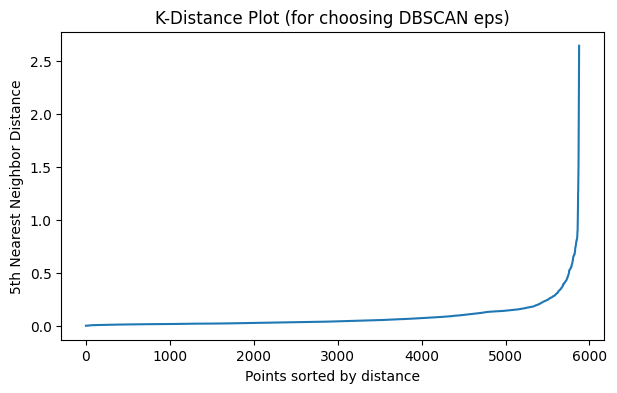

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(distances)
plt.title('K-Distance Plot (for choosing DBSCAN eps)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.show()

In [37]:
from sklearn.cluster import DBSCAN

In [38]:
dbscan = DBSCAN(eps=0.25, min_samples=10)
labels_dbscan = dbscan.fit_predict(rfm_scaled)


In [39]:
unique, counts = np.unique(labels_dbscan, return_counts=True)
print(dict(zip(unique, counts)))

results['DBSCAN'] = labels_dbscan

{np.int64(-1): np.int64(441), np.int64(0): np.int64(5371), np.int64(1): np.int64(38), np.int64(2): np.int64(10), np.int64(3): np.int64(8), np.int64(4): np.int64(10)}


In [40]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


In [41]:
eval_rows = []

for name, labels in results.items():
    mask = labels != -1  # exclude DBSCAN noise points from scoring
    unique_labels = set(labels[mask])
    if len(unique_labels) < 2:
        eval_rows.append({'Algorithm': name, 'Silhouette': None, 'Davies-Bouldin': None,
                           'Calinski-Harabasz': None, 'Clusters Found': len(unique_labels)})
        continue
    sil = silhouette_score(rfm_scaled[mask], labels[mask])
    db = davies_bouldin_score(rfm_scaled[mask], labels[mask])
    ch = calinski_harabasz_score(rfm_scaled[mask], labels[mask])
    eval_rows.append({'Algorithm': name, 'Silhouette': round(sil, 3), 'Davies-Bouldin': round(db, 3),
                       'Calinski-Harabasz': round(ch, 1), 'Clusters Found': len(unique_labels)})

eval_df = pd.DataFrame(eval_rows)
eval_df

,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz,Clusters Found
0,KMeans,0.525,0.717,7360.8,4
1,Hierarchical,0.468,0.790,6286.4,4
2,DBSCAN,0.484,0.481,545.5,5
3,GMM,0.346,1.683,2171.8,4


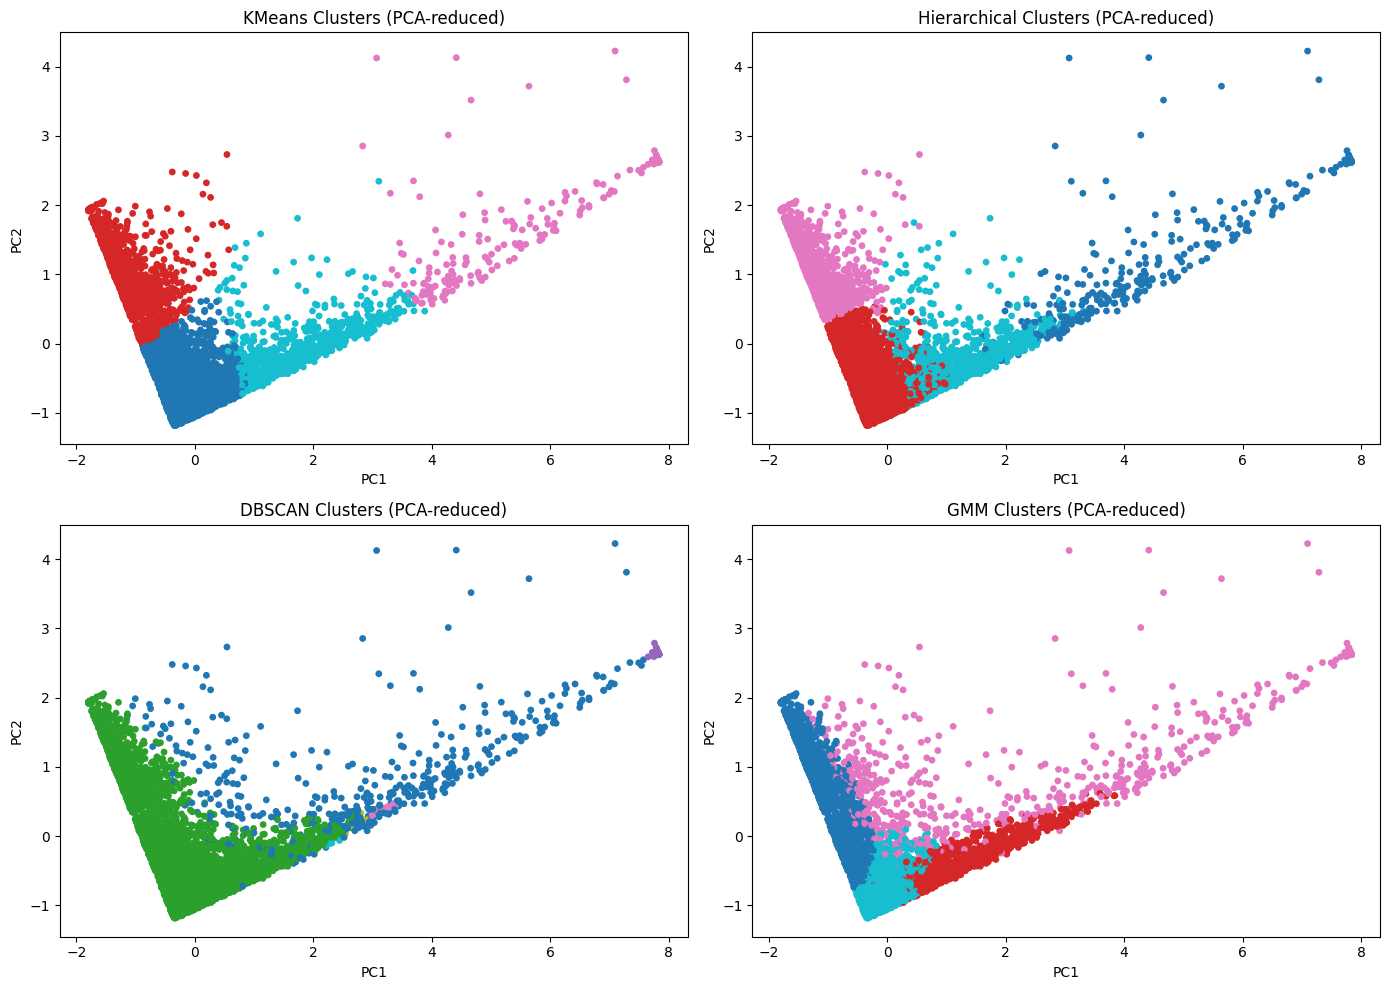

Explained variance by 2 PCA components: 94.10%


In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, labels) in zip(axes, results.items()):
    scatter = ax.scatter(rfm_pca[:, 0], rfm_pca[:, 1], c=labels, cmap='tab10', s=15)
    ax.set_title(f'{name} Clusters (PCA-reduced)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")

In [43]:
# --- Assign the winning algorithm's clusters back to the RFM table ---
BEST_ALGO = 'KMeans'
rfm['Cluster'] = results[BEST_ALGO]

cluster_profile = rfm.groupby('Cluster').agg(
    Recency_mean=('Recency', 'mean'),
    Frequency_mean=('Frequency', 'mean'),
    Monetary_mean=('Monetary', 'mean'),
    Count=('CustomerID', 'count')
).reset_index()

cluster_profile

,Cluster,Recency_mean,Frequency_mean,Monetary_mean,Count
0,0,83.954455,3.792221,1191.482629,3008
1,1,475.186931,2.042314,652.601084,1867
2,2,37.551020,34.413265,20500.055913,196
3,3,44.515489,14.921933,5854.064170,807


/tmp/ipykernel_1500/1458690225.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_profile, x='Cluster', y=col, ax=ax, palette='viridis')
/tmp/ipykernel_1500/1458690225.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_profile, x='Cluster', y=col, ax=ax, palette='viridis')
/tmp/ipykernel_1500/1458690225.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_profile, x='Cluster', y=col, ax=ax, palette='viridis')


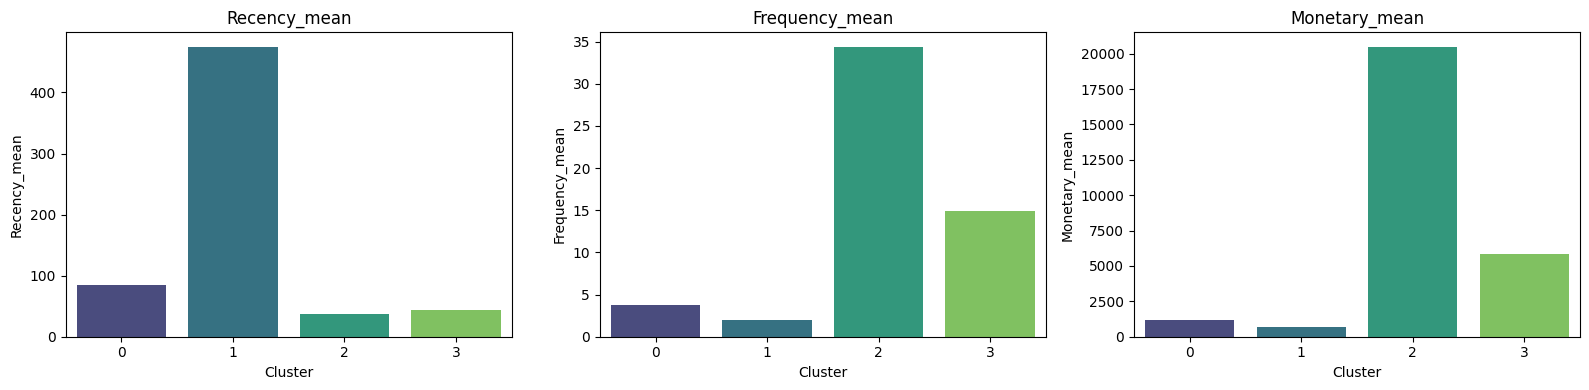

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Recency_mean', 'Frequency_mean', 'Monetary_mean']):
    sns.barplot(data=cluster_profile, x='Cluster', y=col, ax=ax, palette='viridis')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [45]:
total_revenue = rfm['Monetary'].sum()
champions_revenue = rfm[rfm['Cluster'] == 2]['Monetary'].sum()
print(f"Cluster 2 (Champions) is {196/5878:.1%} of customers but {champions_revenue/total_revenue:.1%} of total (capped) revenue")

Cluster 2 (Champions) is 3.3% of customers but 29.7% of total (capped) revenue


In [46]:
import joblib

# Save the trained scaler and KMeans model
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')

# Save the cluster -> label mapping (based on your actual cluster_profile analysis)
cluster_labels = {
    2: "Champions",
    3: "Loyal Customers",
    0: "Regular/Occasional Buyers",
    1: "At-Risk / Lost Customers"
}
joblib.dump(cluster_labels, 'cluster_labels.pkl')

print("Saved: scaler.pkl, kmeans_model.pkl, cluster_labels.pkl")

Saved: scaler.pkl, kmeans_model.pkl, cluster_labels.pkl


In [47]:
import joblib

# Save the trained scaler and KMeans model
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')

# Cluster -> label mapping based on your actual cluster_profile analysis
cluster_labels = {
    2: "Champions",
    3: "Loyal Customers",
    0: "Regular/Occasional Buyers",
    1: "At-Risk / Lost Customers"
}
joblib.dump(cluster_labels, 'cluster_labels.pkl')

# Save the full customer-level data (RFM + assigned cluster) for the dashboard
rfm.to_csv('rfm_with_clusters.csv', index=False)

print("Saved: scaler.pkl, kmeans_model.pkl, cluster_labels.pkl, rfm_with_clusters.csv")

# Download all 4 files
from google.colab import files
files.download('scaler.pkl')
files.download('kmeans_model.pkl')
files.download('cluster_labels.pkl')
files.download('rfm_with_clusters.csv')

Saved: scaler.pkl, kmeans_model.pkl, cluster_labels.pkl, rfm_with_clusters.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')

cluster_labels = {
    2: "Champions",
    3: "Loyal Customers",
    0: "Regular/Occasional Buyers",
    1: "At-Risk / Lost Customers"
}
joblib.dump(cluster_labels, 'cluster_labels.pkl')

rfm.to_csv('rfm_with_clusters.csv', index=False)

from google.colab import files
files.download('scaler.pkl')
files.download('kmeans_model.pkl')
files.download('cluster_labels.pkl')
files.download('rfm_with_clusters.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>